<a href="https://colab.research.google.com/github/tarasovEgor/DeepLearningKurs/blob/main/src/lab_1/cnn_clf_lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Лабораторная работа 1.**

---

## Классификация изображений с использованием CNN, предобработка, аугментация и анализ метрик.

---

## **Цель работы:** изучить основы сверточных нейронных сетей (CNN) в PyTorch, исследовать влияние предобработки, аугментации, архитектуры сети и гиперпараметров на качество классификации изображений.

### 0. Init steps

---

#### Импорты библиотек:

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CyclicLR

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cuda


#### Вспомогательные функции:

---

##### 0.1 Загрузка данных:

In [3]:
def get_transforms(dataset_name, augment=False):
    if dataset_name == "CIFAR10":
        if augment:
            train_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(),
                transforms.RandomCrop(32, padding=4),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
        else:
            train_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])

        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    elif dataset_name == "FashionMNIST":
        if augment:
            train_transform = transforms.Compose([
                transforms.RandomRotation(10),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
        else:
            train_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])

        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    elif dataset_name == "SVHN":
        if augment:
            train_transform = transforms.Compose([
                transforms.ColorJitter(brightness=0.2),
                transforms.RandomRotation(10),
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
        else:
            train_transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])

        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    return train_transform, test_transform


def get_dataloaders(dataset_name, batch_size=64, augment=False):
    train_transform, test_transform = get_transforms(dataset_name, augment)

    if dataset_name == "CIFAR10":
        train_data = datasets.CIFAR10(root="./data", train=True, download=True, transform=train_transform)
        test_data = datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)
        in_channels = 3
        img_size = 32
        num_classes = 10

    elif dataset_name == "FashionMNIST":
        train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
        test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=test_transform)
        in_channels = 1
        img_size = 28
        num_classes = 10

    elif dataset_name == "SVHN":
        train_data = datasets.SVHN(root="./data", split="train", download=True, transform=train_transform)
        test_data = datasets.SVHN(root="./data", split="test", download=True, transform=test_transform)
        in_channels = 3
        img_size = 32
        num_classes = 10

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, in_channels, img_size, num_classes

##### 0.2 Базовая CNN:

In [4]:
class BasicCNN(nn.Module):
    def __init__(
        self,
        in_channels=3,
        num_classes=10,
        img_size=32,
        filters=(32, 64),
        kernel_sizes=(3, 3),
        use_bn=False,
        dropout=0.0,
        pool_type="max"
    ):
        super().__init__()

        k1, k2 = kernel_sizes
        p1 = k1 // 2
        p2 = k2 // 2

        self.conv1 = nn.Conv2d(in_channels, filters[0], kernel_size=k1, padding=p1)
        self.conv2 = nn.Conv2d(filters[0], filters[1], kernel_size=k2, padding=p2)

        self.use_bn = use_bn
        self.bn1 = nn.BatchNorm2d(filters[0])
        self.bn2 = nn.BatchNorm2d(filters[1])

        if pool_type == "max":
            self.pool = nn.MaxPool2d(2, 2)
        else:
            self.pool = nn.AvgPool2d(2, 2)

        self.dropout = nn.Dropout(dropout)

        # После двух pooling размер уменьшается в 4 раза
        feature_size = img_size // 4
        self.fc1 = nn.Linear(filters[1] * feature_size * feature_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

##### 0.3 Более глубокая CNN для 4-й части:

In [5]:
class DeeperCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=10, img_size=32, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)

        feature_size = img_size // 8
        self.fc1 = nn.Linear(128 * feature_size * feature_size, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

##### 0.4 Оценка модели:

In [6]:
def evaluate_model(model, loader, criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = {
        "loss": total_loss / len(loader),
        "acc": correct / total,
        "precision": precision_score(all_labels, all_preds, average="weighted", zero_division=0),
        "recall": recall_score(all_labels, all_preds, average="weighted", zero_division=0),
        "f1": f1_score(all_labels, all_preds, average="weighted", zero_division=0)
    }

    try:
        metrics["roc_auc"] = roc_auc_score(all_labels, np.array(all_probs), multi_class="ovr")
    except:
        metrics["roc_auc"] = None

    return metrics

##### 0.5 Обучение модели:

In [7]:
def train_model(
    model,
    train_loader,
    test_loader,
    epochs=5,
    lr=0.001,
    optimizer_name="adam",
    scheduler_type=None,
    accumulation_steps=1
):
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    scheduler = None
    if scheduler_type == "cyclic":
        scheduler = CyclicLR(
            optimizer,
            base_lr=1e-4,
            max_lr=1e-2,
            step_size_up=max(1, len(train_loader) // 2),
            cycle_momentum=(optimizer_name == "sgd")
        )

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        optimizer.zero_grad()

        for step, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels) / accumulation_steps
            loss.backward()

            if (step + 1) % accumulation_steps == 0:
                optimizer.step()
                optimizer.zero_grad()

                if scheduler is not None:
                    scheduler.step()

            running_loss += loss.item() * accumulation_steps
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        if len(train_loader) % accumulation_steps != 0:
            optimizer.step()
            optimizer.zero_grad()
            if scheduler is not None:
                scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        test_metrics = evaluate_model(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_metrics["loss"])
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_metrics["acc"])

        print(
            f"Эпоха {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Acc: {test_metrics['acc']:.4f}"
        )

    final_test_metrics = evaluate_model(model, test_loader, criterion)
    final_train_metrics = evaluate_model(model, train_loader, criterion)

    return history, final_train_metrics, final_test_metrics

##### 0.6 Визуализация:

In [8]:
def plot_history(history, title="Графики обучения"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()

    plt.show()


def print_metrics(name, metrics):
    print(f"\n{name}")
    print(f"Loss      : {metrics['loss']:.4f}")
    print(f"Accuracy  : {metrics['acc']:.4f}")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F1-score  : {metrics['f1']:.4f}")
    if metrics["roc_auc"] is not None:
        print(f"ROC-AUC   : {metrics['roc_auc']:.4f}")
    else:
        print("ROC-AUC   : не удалось вычислить")

### Часть 1. Базовая CNN для CIFAR-10

#### 1.1 Подготовка данных:

In [9]:
train_loader, test_loader, in_channels, img_size, num_classes = get_dataloaders(
    dataset_name="CIFAR10",
    batch_size=64,
    augment=False
)

100%|██████████| 170M/170M [00:13<00:00, 12.4MB/s]


#### 1.2 Определение архитектуры:

In [10]:
model = BasicCNN(
    in_channels=in_channels,
    num_classes=num_classes,
    img_size=img_size,
    filters=(32, 64),
    kernel_sizes=(3, 3),
    use_bn=False,
    dropout=0.0,
    pool_type="max"
).to(device)

#### 1.3 Обучение:

In [11]:
history_part1, train_metrics_part1, test_metrics_part1 = train_model(
    model,
    train_loader,
    test_loader,
    epochs=10,
    lr=0.001,
    optimizer_name="adam"
)

Эпоха 1/10 | Train Loss: 1.3510 | Train Acc: 0.5172 | Test Acc: 0.6240
Эпоха 2/10 | Train Loss: 0.9705 | Train Acc: 0.6615 | Test Acc: 0.6846
Эпоха 3/10 | Train Loss: 0.8082 | Train Acc: 0.7165 | Test Acc: 0.7042
Эпоха 4/10 | Train Loss: 0.6954 | Train Acc: 0.7576 | Test Acc: 0.7172
Эпоха 5/10 | Train Loss: 0.5950 | Train Acc: 0.7917 | Test Acc: 0.7241
Эпоха 6/10 | Train Loss: 0.5050 | Train Acc: 0.8251 | Test Acc: 0.7240
Эпоха 7/10 | Train Loss: 0.4204 | Train Acc: 0.8526 | Test Acc: 0.7195
Эпоха 8/10 | Train Loss: 0.3377 | Train Acc: 0.8832 | Test Acc: 0.7146
Эпоха 9/10 | Train Loss: 0.2696 | Train Acc: 0.9065 | Test Acc: 0.7142
Эпоха 10/10 | Train Loss: 0.2114 | Train Acc: 0.9273 | Test Acc: 0.7167


#### 1.4 Визуализация и метрики:

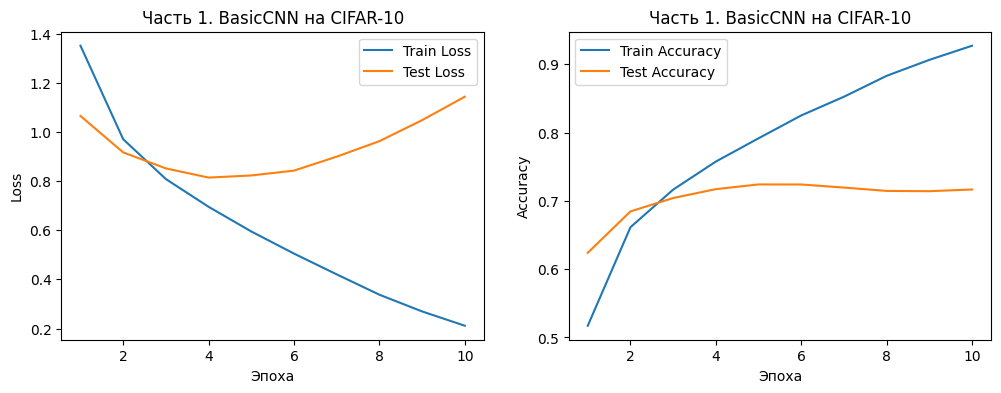


Метрики на обучающей выборке
Loss      : 0.1526
Accuracy  : 0.9516
Precision : 0.9521
Recall    : 0.9516
F1-score  : 0.9516
ROC-AUC   : 0.9986

Метрики на тестовой выборке
Loss      : 1.1435
Accuracy  : 0.7167
Precision : 0.7181
Recall    : 0.7167
F1-score  : 0.7162
ROC-AUC   : 0.9567


In [12]:
plot_history(history_part1, title="Часть 1. BasicCNN на CIFAR-10")

print_metrics("Метрики на обучающей выборке", train_metrics_part1)
print_metrics("Метрики на тестовой выборке", test_metrics_part1)

#### 1.5 Дрполнительная функция - чтобы дальше не дублировать код, добавим функцию:

In [13]:
def run_experiment(
    dataset_name="CIFAR10",
    augment=False,
    batch_size=64,
    epochs=5,
    model_type="basic",
    model_params=None,
    lr=0.001,
    optimizer_name="adam",
    scheduler_type=None,
    accumulation_steps=1
):
    train_loader, test_loader, in_channels, img_size, num_classes = get_dataloaders(
        dataset_name=dataset_name,
        batch_size=batch_size,
        augment=augment
    )

    if model_params is None:
        model_params = {}

    if model_type == "basic":
        model = BasicCNN(
            in_channels=in_channels,
            num_classes=num_classes,
            img_size=img_size,
            **model_params
        ).to(device)
    else:
        model = DeeperCNN(
            in_channels=in_channels,
            num_classes=num_classes,
            img_size=img_size,
            **model_params
        ).to(device)

    history, train_metrics, test_metrics = train_model(
        model,
        train_loader,
        test_loader,
        epochs=epochs,
        lr=lr,
        optimizer_name=optimizer_name,
        scheduler_type=scheduler_type,
        accumulation_steps=accumulation_steps
    )

    return history, train_metrics, test_metrics

#### 1.6 Вывод по первой части:

- Была реализована базовая CNN для классификации изображений CIFAR-10. Модель состояла из двух сверточных слоев, слоев подвыборки MaxPooling и двух полносвязных слоев. В процессе обучения наблюдалось снижение функции потерь и рост точности

### Часть 2. Сравнение датасетов и аугментации

#### 2.1 Cравним CIFAR-10, FashionMNIST, SVHN в двух режимах (без/с аугментацией):

In [15]:
results_part2 = []
histories_part2 = {}

datasets_list = ["CIFAR10", "FashionMNIST", "SVHN"]

for dataset_name in datasets_list:
    for augment in [False, True]:
        print(f"\n----- {dataset_name} | augment={augment} -----")

        history, train_metrics, test_metrics = run_experiment(
            dataset_name=dataset_name,
            augment=augment,
            batch_size=64,
            epochs=5,
            model_type="basic",
            model_params={
                "filters": (32, 64),
                "kernel_sizes": (3, 3),
                "use_bn": True,
                "dropout": 0.2,
                "pool_type": "max"
            },
            lr=0.001,
            optimizer_name="adam"
        )

        exp_name = f"{dataset_name}_{'aug' if augment else 'no_aug'}"
        histories_part2[exp_name] = history

        results_part2.append({
            "dataset": dataset_name,
            "augment": augment,
            "train_acc": train_metrics["acc"],
            "test_acc": test_metrics["acc"],
            "precision": test_metrics["precision"],
            "recall": test_metrics["recall"],
            "f1": test_metrics["f1"],
            "roc_auc": test_metrics["roc_auc"]
        })


----- CIFAR10 | augment=False -----
Эпоха 1/5 | Train Loss: 1.4266 | Train Acc: 0.4823 | Test Acc: 0.6122
Эпоха 2/5 | Train Loss: 1.1051 | Train Acc: 0.6053 | Test Acc: 0.6561
Эпоха 3/5 | Train Loss: 0.9941 | Train Acc: 0.6476 | Test Acc: 0.6868
Эпоха 4/5 | Train Loss: 0.9251 | Train Acc: 0.6711 | Test Acc: 0.6934
Эпоха 5/5 | Train Loss: 0.8810 | Train Acc: 0.6879 | Test Acc: 0.7040

----- CIFAR10 | augment=True -----
Эпоха 1/5 | Train Loss: 1.5778 | Train Acc: 0.4191 | Test Acc: 0.5454
Эпоха 2/5 | Train Loss: 1.3122 | Train Acc: 0.5233 | Test Acc: 0.6136
Эпоха 3/5 | Train Loss: 1.2092 | Train Acc: 0.5639 | Test Acc: 0.6490
Эпоха 4/5 | Train Loss: 1.1540 | Train Acc: 0.5894 | Test Acc: 0.6501
Эпоха 5/5 | Train Loss: 1.1117 | Train Acc: 0.6024 | Test Acc: 0.6799

----- FashionMNIST | augment=False -----


100%|██████████| 26.4M/26.4M [00:02<00:00, 9.75MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 151kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.91MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


Эпоха 1/5 | Train Loss: 0.4139 | Train Acc: 0.8492 | Test Acc: 0.8820
Эпоха 2/5 | Train Loss: 0.2821 | Train Acc: 0.8969 | Test Acc: 0.9003
Эпоха 3/5 | Train Loss: 0.2436 | Train Acc: 0.9099 | Test Acc: 0.8995
Эпоха 4/5 | Train Loss: 0.2174 | Train Acc: 0.9200 | Test Acc: 0.9096
Эпоха 5/5 | Train Loss: 0.1966 | Train Acc: 0.9286 | Test Acc: 0.9183

----- FashionMNIST | augment=True -----
Эпоха 1/5 | Train Loss: 0.4704 | Train Acc: 0.8265 | Test Acc: 0.8710
Эпоха 2/5 | Train Loss: 0.3371 | Train Acc: 0.8764 | Test Acc: 0.8882
Эпоха 3/5 | Train Loss: 0.2983 | Train Acc: 0.8902 | Test Acc: 0.8970
Эпоха 4/5 | Train Loss: 0.2754 | Train Acc: 0.8987 | Test Acc: 0.8982
Эпоха 5/5 | Train Loss: 0.2622 | Train Acc: 0.9037 | Test Acc: 0.9121

----- SVHN | augment=False -----


100%|██████████| 182M/182M [00:28<00:00, 6.37MB/s]
100%|██████████| 64.3M/64.3M [00:10<00:00, 5.88MB/s]


Эпоха 1/5 | Train Loss: 1.0691 | Train Acc: 0.6322 | Test Acc: 0.7984
Эпоха 2/5 | Train Loss: 0.7387 | Train Acc: 0.7527 | Test Acc: 0.8333
Эпоха 3/5 | Train Loss: 0.6695 | Train Acc: 0.7766 | Test Acc: 0.8348
Эпоха 4/5 | Train Loss: 0.6282 | Train Acc: 0.7900 | Test Acc: 0.8519
Эпоха 5/5 | Train Loss: 0.5935 | Train Acc: 0.8036 | Test Acc: 0.8581

----- SVHN | augment=True -----
Эпоха 1/5 | Train Loss: 1.3185 | Train Acc: 0.5410 | Test Acc: 0.7869
Эпоха 2/5 | Train Loss: 0.9495 | Train Acc: 0.6777 | Test Acc: 0.8002
Эпоха 3/5 | Train Loss: 0.8788 | Train Acc: 0.7008 | Test Acc: 0.8284
Эпоха 4/5 | Train Loss: 0.8365 | Train Acc: 0.7159 | Test Acc: 0.8375
Эпоха 5/5 | Train Loss: 0.8037 | Train Acc: 0.7296 | Test Acc: 0.8404


#### 2.2 Построим таблицу результатов, отсортируем по качеству на тестовой выборке:

In [16]:
results_part2_df = pd.DataFrame(results_part2)
print(results_part2_df)

        dataset  augment  train_acc  test_acc  precision    recall        f1  \
0       CIFAR10    False   0.757980  0.704000   0.707258  0.704000  0.700998   
1       CIFAR10     True   0.639440  0.679900   0.687812  0.679900  0.676414   
2  FashionMNIST    False   0.945817  0.918300   0.918383  0.918300  0.918135   
3  FashionMNIST     True   0.922067  0.912100   0.911283  0.912100  0.911100   
4          SVHN    False   0.891478  0.858136   0.858687  0.858136  0.857731   
5          SVHN     True   0.845339  0.840350   0.839653  0.840350  0.839101   

    roc_auc  
0  0.957644  
1  0.952006  
2  0.995252  
3  0.994367  
4  0.983415  
5  0.978870  


In [17]:
print(results_part2_df.sort_values(by="test_acc", ascending=False))

        dataset  augment  train_acc  test_acc  precision    recall        f1  \
2  FashionMNIST    False   0.945817  0.918300   0.918383  0.918300  0.918135   
3  FashionMNIST     True   0.922067  0.912100   0.911283  0.912100  0.911100   
4          SVHN    False   0.891478  0.858136   0.858687  0.858136  0.857731   
5          SVHN     True   0.845339  0.840350   0.839653  0.840350  0.839101   
0       CIFAR10    False   0.757980  0.704000   0.707258  0.704000  0.700998   
1       CIFAR10     True   0.639440  0.679900   0.687812  0.679900  0.676414   

    roc_auc  
2  0.995252  
3  0.994367  
4  0.983415  
5  0.978870  
0  0.957644  
1  0.952006  


#### 2.3 Выполним сравнение “с аугментацией / без аугментации”:

In [18]:
comparison_part2 = results_part2_df.pivot(index="dataset", columns="augment", values="test_acc")
comparison_part2.columns = ["no_aug", "aug"]
comparison_part2["improvement"] = comparison_part2["aug"] - comparison_part2["no_aug"]

print(comparison_part2)

                no_aug      aug  improvement
dataset                                     
CIFAR10       0.704000  0.67990    -0.024100
FashionMNIST  0.918300  0.91210    -0.006200
SVHN          0.858136  0.84035    -0.017786


#### 2.4 Выведем графики:

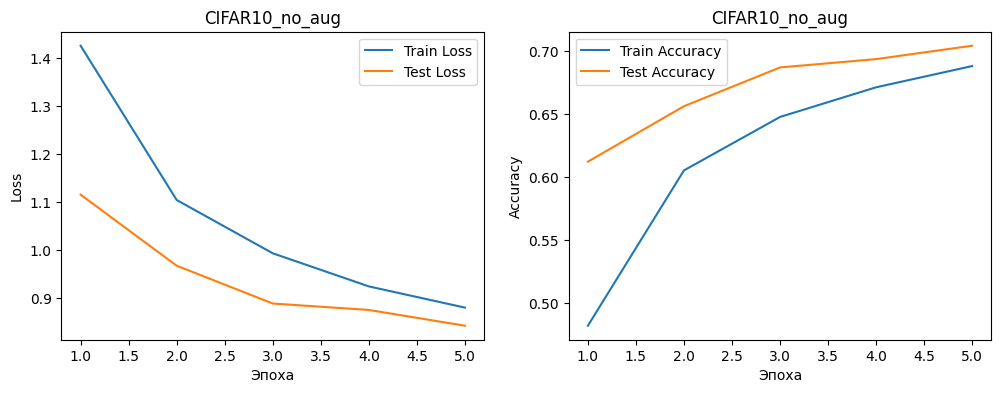

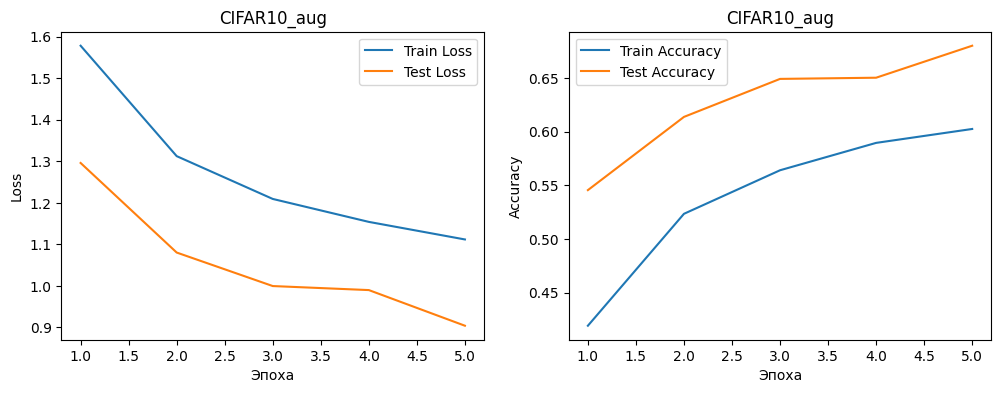

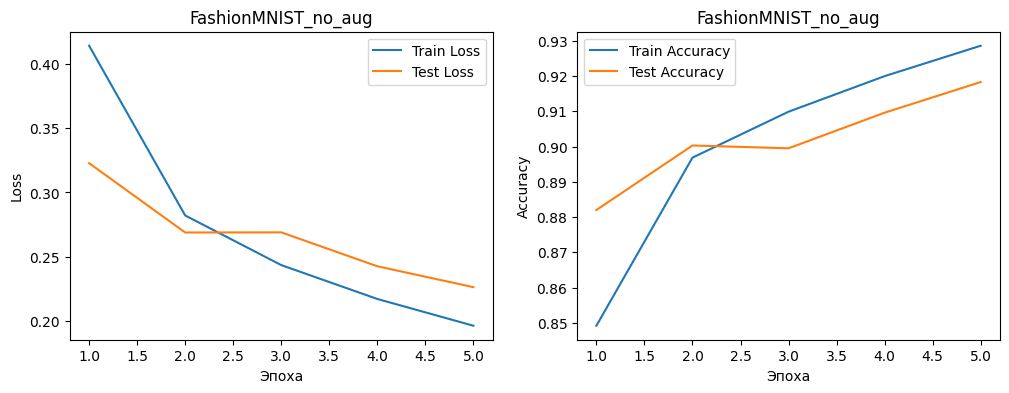

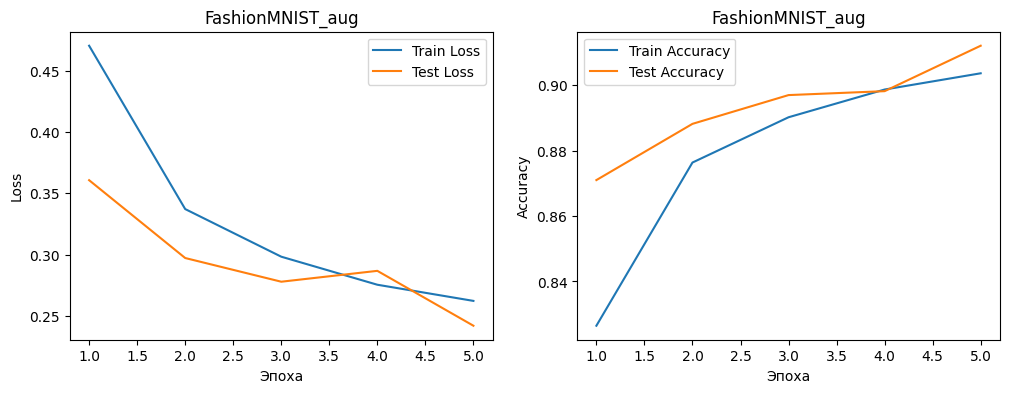

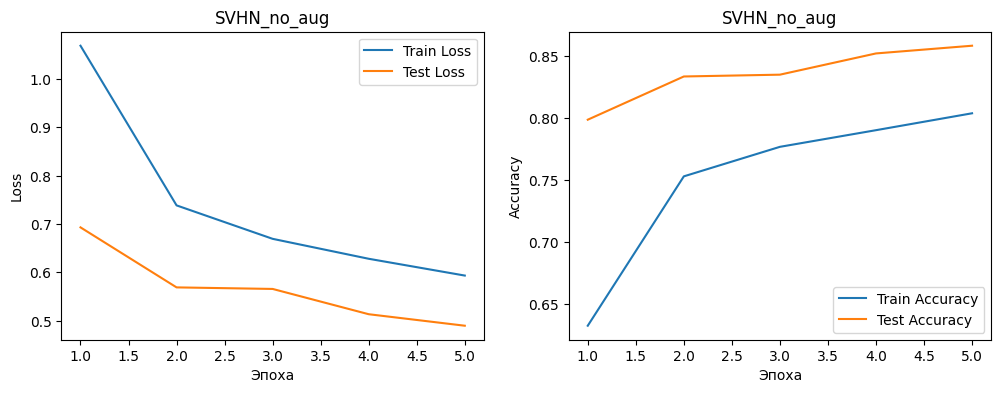

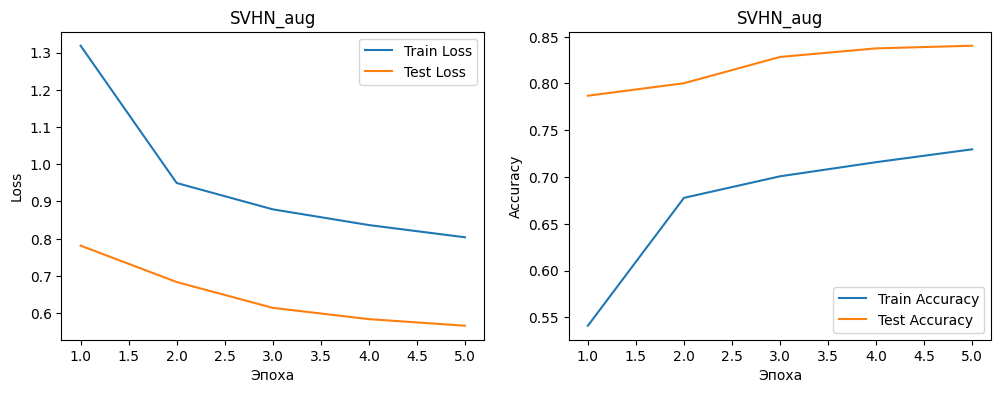

In [20]:
for name, history in histories_part2.items():
    plot_history(history, title=f"{name}")

#### 2.5 Вывод по второй части:

-

### Часть 3. Оптимизация архитектуры CNN

### 3.1 Проведем сравнение трех вариантов: (маленькая/средняя/более крупная модель) на **CIFAR-10**:

In [22]:
results_part3 = []
histories_part3 = {}

model_configs = [
    {
        "name": "Model_1_small",
        "model_type": "basic",
        "model_params": {
            "filters": (16, 32),
            "kernel_sizes": (3, 3),
            "use_bn": False,
            "dropout": 0.0,
            "pool_type": "max"
        }
    },
    {
        "name": "Model_2_bn_dropout",
        "model_type": "basic",
        "model_params": {
            "filters": (32, 64),
            "kernel_sizes": (3, 3),
            "use_bn": True,
            "dropout": 0.3,
            "pool_type": "max"
        }
    },
    {
        "name": "Model_3_large_kernels",
        "model_type": "basic",
        "model_params": {
            "filters": (64, 128),
            "kernel_sizes": (5, 5),
            "use_bn": True,
            "dropout": 0.3,
            "pool_type": "max"
        }
    }
]

for cfg in model_configs:
    print(f"\n----- {cfg['name']} -----")

    history, train_metrics, test_metrics = run_experiment(
        dataset_name="CIFAR10",
        augment=True,
        batch_size=64,
        epochs=5,
        model_type=cfg["model_type"],
        model_params=cfg["model_params"],
        lr=0.001,
        optimizer_name="adam"
    )

    histories_part3[cfg["name"]] = history

    results_part3.append({
        "model": cfg["name"],
        "train_acc": train_metrics["acc"],
        "test_acc": test_metrics["acc"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "roc_auc": test_metrics["roc_auc"]
    })


----- Model_1_small -----
Эпоха 1/5 | Train Loss: 1.5999 | Train Acc: 0.4156 | Test Acc: 0.5459
Эпоха 2/5 | Train Loss: 1.3113 | Train Acc: 0.5284 | Test Acc: 0.5953
Эпоха 3/5 | Train Loss: 1.1820 | Train Acc: 0.5803 | Test Acc: 0.6118
Эпоха 4/5 | Train Loss: 1.1077 | Train Acc: 0.6035 | Test Acc: 0.6495
Эпоха 5/5 | Train Loss: 1.0513 | Train Acc: 0.6263 | Test Acc: 0.6647

----- Model_2_bn_dropout -----
Эпоха 1/5 | Train Loss: 1.6830 | Train Acc: 0.3731 | Test Acc: 0.5168
Эпоха 2/5 | Train Loss: 1.4077 | Train Acc: 0.4862 | Test Acc: 0.6047
Эпоха 3/5 | Train Loss: 1.2997 | Train Acc: 0.5288 | Test Acc: 0.6219
Эпоха 4/5 | Train Loss: 1.2410 | Train Acc: 0.5551 | Test Acc: 0.6492
Эпоха 5/5 | Train Loss: 1.1979 | Train Acc: 0.5723 | Test Acc: 0.6559

----- Model_3_large_kernels -----
Эпоха 1/5 | Train Loss: 1.8021 | Train Acc: 0.3236 | Test Acc: 0.4736
Эпоха 2/5 | Train Loss: 1.5583 | Train Acc: 0.4137 | Test Acc: 0.5270
Эпоха 3/5 | Train Loss: 1.4646 | Train Acc: 0.4511 | Test Acc: 0.5

#### 3.2 Таблица результатов:

In [23]:
results_part3_df = pd.DataFrame(results_part3)
print(results_part3_df.sort_values(by="test_acc", ascending=False))

                   model  train_acc  test_acc  precision  recall        f1  \
0          Model_1_small    0.64496    0.6647   0.669420  0.6647  0.660762   
1     Model_2_bn_dropout    0.62440    0.6559   0.660324  0.6559  0.649303   
2  Model_3_large_kernels    0.59788    0.6185   0.629829  0.6185  0.607882   

    roc_auc  
0  0.947556  
1  0.944059  
2  0.935852  


#### 3.3 Построение графиков:

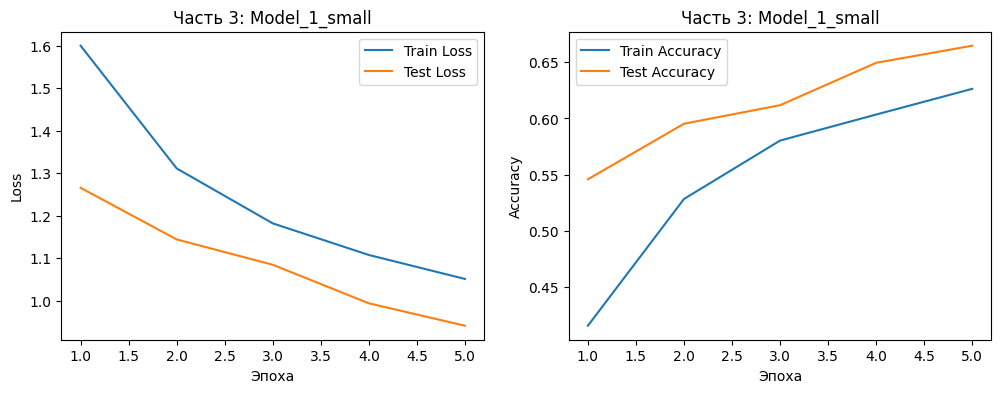

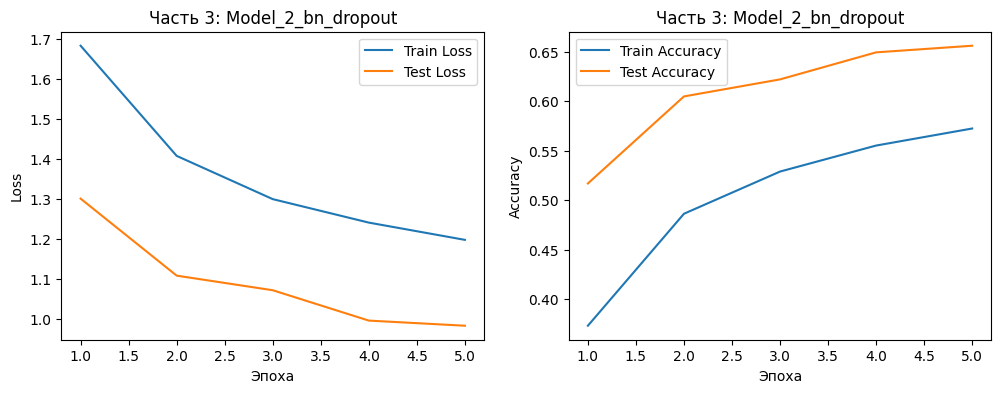

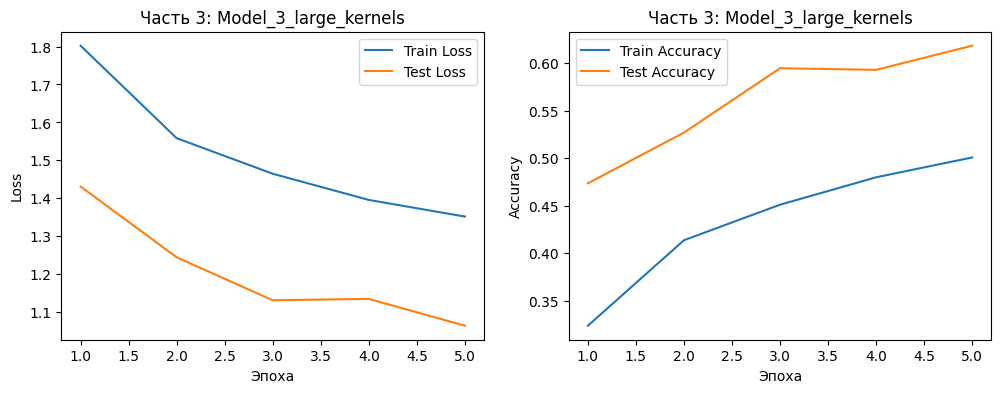

In [24]:
for name, history in histories_part3.items():
    plot_history(history, title=f"Часть 3: {name}")

### Часть 4. Оптимизация гиперпараметров

#### 4.1 Возьмем одну “сбалансированную” архитектуру и сравним:
  - Adam — адаптивный learning rate
  - SGD + CyclicLR — циклический learning rate
  - разные batch size
  - gradient accumulation

Для простоты используем архитектуру из части 3:

In [25]:
best_model_params = {
    "filters": (32, 64),
    "kernel_sizes": (3, 3),
    "use_bn": True,
    "dropout": 0.3,
    "pool_type": "max"
}

#### 4.2 Сравнение Adam и SGD + CyclicLR:

In [26]:
results_part4 = []
histories_part4 = {}

experiments_lr = [
    {
        "name": "Adam_lr_0.001",
        "optimizer_name": "adam",
        "lr": 0.001,
        "scheduler_type": None,
        "batch_size": 64,
        "accumulation_steps": 1
    },
    {
        "name": "SGD_CyclicLR",
        "optimizer_name": "sgd",
        "lr": 0.001,
        "scheduler_type": "cyclic",
        "batch_size": 64,
        "accumulation_steps": 1
    }
]

for exp in experiments_lr:
    print(f"\n---- {exp['name']} -----")

    history, train_metrics, test_metrics = run_experiment(
        dataset_name="CIFAR10",
        augment=True,
        batch_size=exp["batch_size"],
        epochs=5,
        model_type="basic",
        model_params=best_model_params,
        lr=exp["lr"],
        optimizer_name=exp["optimizer_name"],
        scheduler_type=exp["scheduler_type"],
        accumulation_steps=exp["accumulation_steps"]
    )

    histories_part4[exp["name"]] = history

    results_part4.append({
        "experiment": exp["name"],
        "train_acc": train_metrics["acc"],
        "test_acc": test_metrics["acc"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "roc_auc": test_metrics["roc_auc"]
    })


===== Adam_lr_0.001 =====


KeyboardInterrupt: 

#### 4.3 Сравнение batch size и gradient accumulation:

In [ ]:
experiments_batch = [
    {
        "name": "Batch_32",
        "optimizer_name": "adam",
        "lr": 0.001,
        "scheduler_type": None,
        "batch_size": 32,
        "accumulation_steps": 1
    },
    {
        "name": "Batch_128",
        "optimizer_name": "adam",
        "lr": 0.001,
        "scheduler_type": None,
        "batch_size": 128,
        "accumulation_steps": 1
    },
    {
        "name": "Batch_32_Accum_4",
        "optimizer_name": "adam",
        "lr": 0.001,
        "scheduler_type": None,
        "batch_size": 32,
        "accumulation_steps": 4
    }
]

for exp in experiments_batch:
    print(f"\n===== {exp['name']} =====")

    history, train_metrics, test_metrics = run_experiment(
        dataset_name="CIFAR10",
        augment=True,
        batch_size=exp["batch_size"],
        epochs=5,
        model_type="basic",
        model_params=best_model_params,
        lr=exp["lr"],
        optimizer_name=exp["optimizer_name"],
        scheduler_type=exp["scheduler_type"],
        accumulation_steps=exp["accumulation_steps"]
    )

    histories_part4[exp["name"]] = history

    results_part4.append({
        "experiment": exp["name"],
        "train_acc": train_metrics["acc"],
        "test_acc": test_metrics["acc"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "roc_auc": test_metrics["roc_auc"]
    })

#### 4.4 Итоговая таблица:

In [ ]:
results_part4_df = pd.DataFrame(results_part4)
print(results_part4_df.sort_values(by="test_acc", ascending=False))

#### 4.5 Построим графики:

In [ ]:
for name, history in histories_part4.items():
    plot_history(history, title=f"Часть 4: {name}")